# Credit Card Fraud Detection with Spark MLlib

**Business question**: Given a credit card transaction's features, can we accurately detect fraudulent transactions?

Credit card fraud costs the financial industry billions annually. This notebook builds a **fraud detection system** using Spark MLlib on the Kaggle credit card fraud dataset (284,807 transactions). The core challenge: only **0.17% of transactions are fraudulent** — a severe class imbalance that renders naive accuracy useless.

We will:
1. Load and explore the dataset
2. Analyze fraud patterns by time and amount
3. Handle class imbalance with class weighting
4. Train two models: **Logistic Regression** and **Decision Tree**
5. Evaluate with imbalance-aware metrics (AUPRC, F1, Precision, Recall)
6. Compare models and visualize results

**Dataset**: 284,807 European cardholder transactions over 2 days (Sept 2013). 30 features (Time, V1-V28 PCA components, Amount) and a binary label (Class: 0=legitimate, 1=fraud).

In [ ]:
# --- Download dataset from Kaggle (if not already present) ---
import os, subprocess, sys

data_path = "../data/creditcard.csv"

if not os.path.exists(data_path):
    print("creditcard.csv not found — downloading from Kaggle...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
    import kagglehub
    download_path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
    import shutil
    src = os.path.join(download_path, "creditcard.csv")
    shutil.copy(src, data_path)
    print(f"✓ Downloaded and copied to {data_path}")
else:
    print(f"✓ Dataset already exists at {data_path}")

In [1]:
%matplotlib inline
import time

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, count, sum as spark_sum, avg,
    min as spark_min, max as spark_max,
    round as spark_round, floor, lit
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import numpy as np

spark = SparkSession.builder \
    .appName("11 - Fraud Detection") \
    .master("local[*]") \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


---
## 1. Load and Inspect the Dataset

The dataset contains 284,807 credit card transactions made by European cardholders over two days in September 2013. Features V1–V28 are principal components from PCA (original features withheld for confidentiality). Only **Time**, **Amount**, and **Class** are untransformed.

In [2]:
df = spark.read.csv("../data/creditcard.csv", header=True, inferSchema=True)

print(f"Rows:    {df.count():,}")
print(f"Columns: {len(df.columns)}")
print(f"\nColumn names: {df.columns}")
df.printSchema()

Rows:    284,807
Columns: 31

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21:

In [3]:
df.show(5, truncate=False)

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|V1                |V2                 |V3              |V4                |V5                 |V6                 |V7                 |V8                |V9                |V10                |V11               |V12               |V13               |V14               |V15               |V16               |V17               |V18                |V19               |V20                |V21                 |V22                |V23  

In [4]:
df.select("Time", "Amount", "Class").describe().show()

+-------+------------------+-----------------+--------------------+
|summary|              Time|           Amount|               Class|
+-------+------------------+-----------------+--------------------+
|  count|            284807|           284807|              284807|
|   mean| 94813.85957508067| 88.3496192509521|0.001727485630620034|
| stddev|47488.145954566324|250.1201092401885|0.041527189635464985|
|    min|               0.0|              0.0|                   0|
|    max|          172792.0|         25691.16|                   1|
+-------+------------------+-----------------+--------------------+



In [5]:
# Class distribution
class_counts = df.groupBy("Class").agg(
    count("*").alias("count")
).orderBy("Class")

class_counts.show()

total = df.count()
fraud_count = df.filter(col("Class") == 1).count()
legit_count = total - fraud_count

print(f"Total transactions:   {total:,}")
print(f"Legitimate (Class=0): {legit_count:,} ({legit_count/total*100:.2f}%)")
print(f"Fraudulent (Class=1): {fraud_count:,} ({fraud_count/total*100:.3f}%)")
print(f"Imbalance ratio:      1 fraud per {legit_count // fraud_count:,} legitimate transactions")

+-----+------+
|Class| count|
+-----+------+
|    0|284315|
|    1|   492|
+-----+------+

Total transactions:   284,807
Legitimate (Class=0): 284,315 (99.83%)
Fraudulent (Class=1): 492 (0.173%)
Imbalance ratio:      1 fraud per 577 legitimate transactions


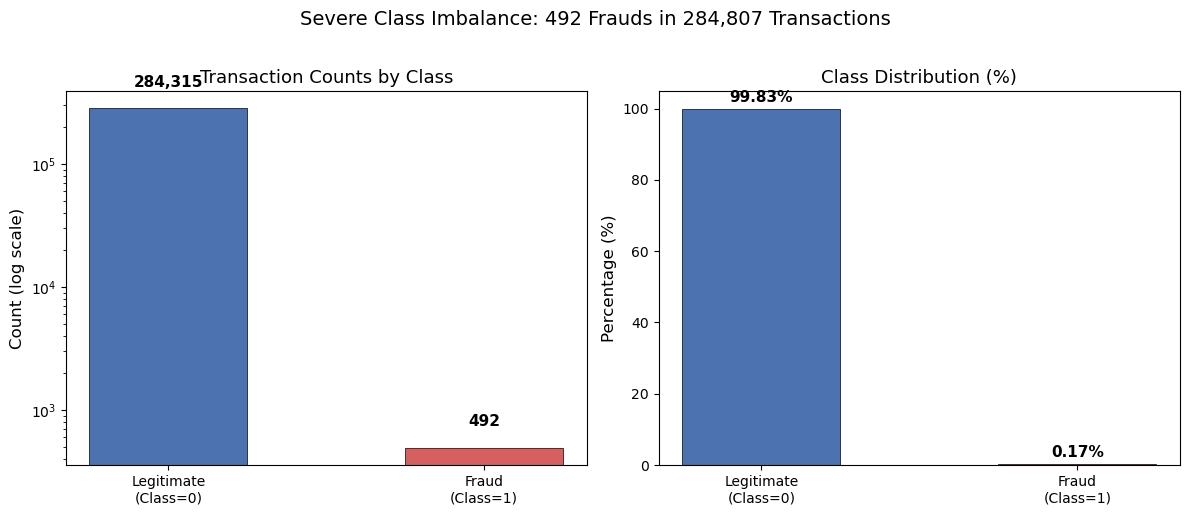

In [6]:
# Chart 1: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

classes = ["Legitimate\n(Class=0)", "Fraud\n(Class=1)"]
counts = [legit_count, fraud_count]
colors = ["#4C72B0", "#D65F5F"]

# Left: raw counts (log scale)
axes[0].bar(classes, counts, color=colors, edgecolor="k", linewidth=0.5, width=0.5)
axes[0].set_yscale("log")
axes[0].set_ylabel("Count (log scale)", fontsize=12)
axes[0].set_title("Transaction Counts by Class", fontsize=13)
for i, v in enumerate(counts):
    axes[0].text(i, v * 1.5, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

# Right: percentage
pcts = [legit_count / total * 100, fraud_count / total * 100]
axes[1].bar(classes, pcts, color=colors, edgecolor="k", linewidth=0.5, width=0.5)
axes[1].set_ylabel("Percentage (%)", fontsize=12)
axes[1].set_title("Class Distribution (%)", fontsize=13)
for i, v in enumerate(pcts):
    axes[1].text(i, v + max(pcts) * 0.02, f"{v:.2f}%", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Severe Class Imbalance: 492 Frauds in 284,807 Transactions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. User Behavior Analysis

We derive `hour_of_day` from the Time column (seconds elapsed since the first transaction) and examine how fraud patterns vary by **time of day** and **transaction amount**.

In [7]:
# Convert Time (seconds from first tx) to hour of day
df = df.withColumn("hour_of_day", (floor(col("Time") % 86400 / 3600)).cast("int"))

print("Transactions by hour of day:")
df.groupBy("hour_of_day").agg(count("*").alias("count")) \
    .orderBy("hour_of_day").show(24)

Transactions by hour of day:
+-----------+-----+
|hour_of_day|count|
+-----------+-----+
|          0| 7695|
|          1| 4220|
|          2| 3328|
|          3| 3492|
|          4| 2209|
|          5| 2990|
|          6| 4101|
|          7| 7243|
|          8|10276|
|          9|15838|
|         10|16598|
|         11|16856|
|         12|15420|
|         13|15365|
|         14|16570|
|         15|16461|
|         16|16453|
|         17|16166|
|         18|17039|
|         19|15649|
|         20|16756|
|         21|17703|
|         22|15441|
|         23|10938|
+-----------+-----+



In [8]:
# Fraud rate by hour of day
hourly_fraud = df.groupBy("hour_of_day").agg(
    count("*").alias("total"),
    spark_sum(col("Class")).cast("int").alias("fraud_count")
).withColumn(
    "fraud_rate_pct", spark_round(col("fraud_count") / col("total") * 100, 4)
).orderBy("hour_of_day")

print("Fraud rate by hour of day:")
hourly_fraud.show(24)

Fraud rate by hour of day:
+-----------+-----+-----------+--------------+
|hour_of_day|total|fraud_count|fraud_rate_pct|
+-----------+-----+-----------+--------------+
|          0| 7695|          6|         0.078|
|          1| 4220|         10|         0.237|
|          2| 3328|         57|        1.7127|
|          3| 3492|         17|        0.4868|
|          4| 2209|         23|        1.0412|
|          5| 2990|         11|        0.3679|
|          6| 4101|          9|        0.2195|
|          7| 7243|         23|        0.3175|
|          8|10276|          9|        0.0876|
|          9|15838|         16|         0.101|
|         10|16598|          8|        0.0482|
|         11|16856|         53|        0.3144|
|         12|15420|         17|        0.1102|
|         13|15365|         17|        0.1106|
|         14|16570|         23|        0.1388|
|         15|16461|         26|        0.1579|
|         16|16453|         22|        0.1337|
|         17|16166|         29|  

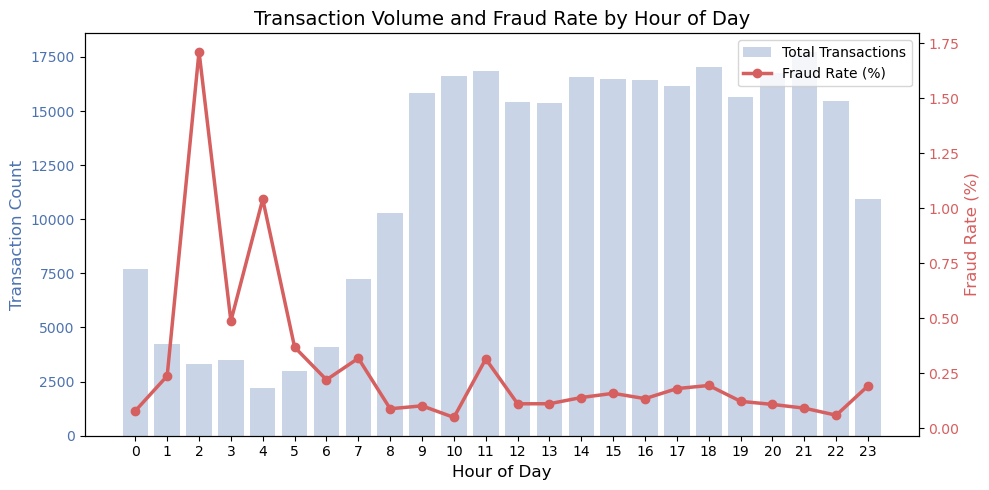

In [9]:
# Chart 2: Fraud rate by hour of day (dual-axis)
hourly_pdf = hourly_fraud.toPandas()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars: transaction volume
ax1.bar(hourly_pdf["hour_of_day"], hourly_pdf["total"],
        color="#4C72B0", alpha=0.3, label="Total Transactions")
ax1.set_xlabel("Hour of Day", fontsize=12)
ax1.set_ylabel("Transaction Count", fontsize=12, color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

# Line: fraud rate on secondary axis
ax2 = ax1.twinx()
ax2.plot(hourly_pdf["hour_of_day"], hourly_pdf["fraud_rate_pct"],
         color="#D65F5F", linewidth=2.5, marker="o", markersize=6, label="Fraud Rate (%)")
ax2.set_ylabel("Fraud Rate (%)", fontsize=12, color="#D65F5F")
ax2.tick_params(axis="y", labelcolor="#D65F5F")

ax1.set_title("Transaction Volume and Fraud Rate by Hour of Day", fontsize=14)
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
# Fraud analysis by transaction amount
print("Transaction Amount Statistics: Fraud vs Legitimate\n")
df.groupBy("Class").agg(
    spark_round(avg("Amount"), 2).alias("avg_amount"),
    spark_round(spark_min("Amount"), 2).alias("min_amount"),
    spark_round(spark_max("Amount"), 2).alias("max_amount"),
    count("*").alias("count")
).orderBy("Class").show()

# Fraud rate by amount bucket
amount_buckets = df.withColumn(
    "amount_bucket",
    when(col("Amount") <= 10, "$0-10")
    .when(col("Amount") <= 50, "$10-50")
    .when(col("Amount") <= 100, "$50-100")
    .when(col("Amount") <= 500, "$100-500")
    .when(col("Amount") <= 1000, "$500-1000")
    .otherwise("$1000+")
)

bucket_fraud = amount_buckets.groupBy("amount_bucket").agg(
    count("*").alias("total"),
    spark_sum(col("Class")).cast("int").alias("fraud_count")
).withColumn(
    "fraud_rate_pct", spark_round(col("fraud_count") / col("total") * 100, 4)
)

print("Fraud rate by transaction amount bucket:")
bucket_fraud.orderBy(col("fraud_rate_pct").desc()).show()

Transaction Amount Statistics: Fraud vs Legitimate

+-----+----------+----------+----------+------+
|Class|avg_amount|min_amount|max_amount| count|
+-----+----------+----------+----------+------+
|    0|     88.29|       0.0|  25691.16|284315|
|    1|    122.21|       0.0|   2125.87|   492|
+-----+----------+----------+----------+------+

Fraud rate by transaction amount bucket:
+-------------+------+-----------+--------------+
|amount_bucket| total|fraud_count|fraud_rate_pct|
+-------------+------+-----------+--------------+
|    $500-1000|  6202|         26|        0.4192|
|       $1000+|  2940|          9|        0.3061|
|        $0-10|100264|        249|        0.2483|
|     $100-500| 47366|         95|        0.2006|
|      $50-100| 37254|         56|        0.1503|
|       $10-50| 90781|         57|        0.0628|
+-------------+------+-----------+--------------+



/tmp/ipykernel_3992/4164392064.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([legit_amounts, fraud_amounts],


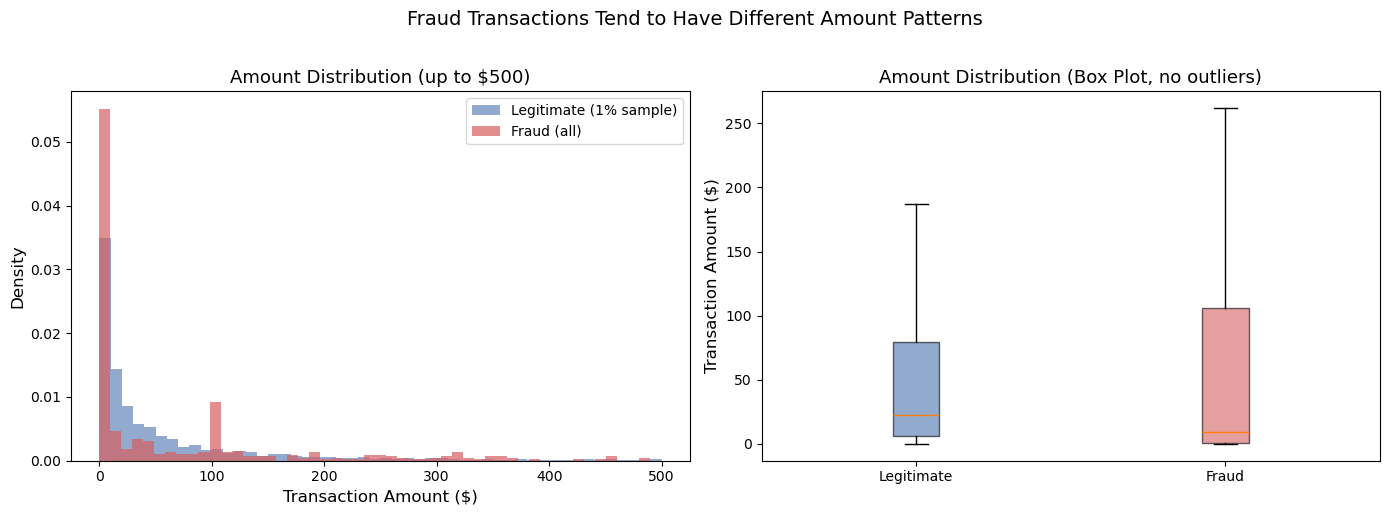

In [11]:
# Chart 3: Transaction amount distributions -- fraud vs legitimate
fraud_amounts = df.filter(col("Class") == 1).select("Amount").toPandas()["Amount"]
legit_amounts = df.filter(col("Class") == 0).sample(fraction=0.01, seed=42) \
    .select("Amount").toPandas()["Amount"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms (capped at $500)
axes[0].hist(legit_amounts[legit_amounts <= 500], bins=50, alpha=0.6,
             color="#4C72B0", label="Legitimate (1% sample)", density=True)
axes[0].hist(fraud_amounts[fraud_amounts <= 500], bins=50, alpha=0.7,
             color="#D65F5F", label="Fraud (all)", density=True)
axes[0].set_xlabel("Transaction Amount ($)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].set_title("Amount Distribution (up to $500)", fontsize=13)
axes[0].legend(fontsize=10)

# Right: box plot comparison (no outliers for readability)
bp = axes[1].boxplot([legit_amounts, fraud_amounts],
                     labels=["Legitimate", "Fraud"],
                     patch_artist=True, showfliers=False)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("#D65F5F")
bp["boxes"][1].set_alpha(0.6)
axes[1].set_ylabel("Transaction Amount ($)", fontsize=12)
axes[1].set_title("Amount Distribution (Box Plot, no outliers)", fontsize=13)

plt.suptitle("Fraud Transactions Tend to Have Different Amount Patterns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Most discriminating PCA components
v_cols = [f"V{i}" for i in range(1, 29)]
agg_exprs = [spark_round(avg(c), 4).alias(c) for c in v_cols]

fraud_means = df.filter(col("Class") == 1).agg(*agg_exprs).toPandas().iloc[0]
legit_means = df.filter(col("Class") == 0).agg(*agg_exprs).toPandas().iloc[0]

diffs = abs(fraud_means - legit_means).sort_values(ascending=False)

print("Top 10 most discriminating PCA components (by |mean_fraud - mean_legit|):\n")
for feat, diff in diffs.head(10).items():
    print(f"  {feat:>4}: diff = {diff:>8.4f}  (fraud mean = {fraud_means[feat]:>8.4f}, legit mean = {legit_means[feat]:>8.4f})")

Top 10 most discriminating PCA components (by |mean_fraud - mean_legit|):

    V3: diff =   7.0455  (fraud mean =  -7.0333, legit mean =   0.0122)
   V14: diff =   6.9838  (fraud mean =  -6.9717, legit mean =   0.0121)
   V17: diff =   6.6773  (fraud mean =  -6.6658, legit mean =   0.0115)
   V12: diff =   6.2702  (fraud mean =  -6.2594, legit mean =   0.0108)
   V10: diff =   5.6867  (fraud mean =  -5.6769, legit mean =   0.0098)
    V7: diff =   5.5783  (fraud mean =  -5.5687, legit mean =   0.0096)
    V1: diff =   4.7802  (fraud mean =  -4.7719, legit mean =   0.0083)
    V4: diff =   4.5499  (fraud mean =   4.5420, legit mean =  -0.0079)
   V16: diff =   4.1471  (fraud mean =  -4.1399, legit mean =   0.0072)
   V11: diff =   3.8068  (fraud mean =   3.8002, legit mean =  -0.0066)


---
## 3. Feature Preparation

Before modeling, we need to:
1. **Assemble features** into a single vector column (V1–V28 + Amount + hour_of_day)
2. **Scale features** with StandardScaler (important for Logistic Regression)
3. **Add class weights** to handle the severe imbalance (fraud gets ~578× weight)
4. **Split** into train/test sets

**Why class weighting?** With 99.83% legitimate transactions, a model that always predicts "not fraud" gets 99.83% accuracy but catches zero fraud. By weighting fraud samples ~289× higher, the model treats each fraud as important as hundreds of legitimate transactions during training.

In [13]:
# Define feature columns
feature_cols = [f"V{i}" for i in range(1, 29)] + ["Amount", "hour_of_day"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")

print(f"Feature columns ({len(feature_cols)}):")
for i, c in enumerate(feature_cols):
    print(f"  [{i:>2}] {c}")

Feature columns (30):
  [ 0] V1
  [ 1] V2
  [ 2] V3
  [ 3] V4
  [ 4] V5
  [ 5] V6
  [ 6] V7
  [ 7] V8
  [ 8] V9
  [ 9] V10
  [10] V11
  [11] V12
  [12] V13
  [13] V14
  [14] V15
  [15] V16
  [16] V17
  [17] V18
  [18] V19
  [19] V20
  [20] V21
  [21] V22
  [22] V23
  [23] V24
  [24] V25
  [25] V26
  [26] V27
  [27] V28
  [28] Amount
  [29] hour_of_day


In [14]:
# Class weighting: balance fraud (minority) vs legitimate (majority)
# Formula: weight = (total / class_count) / 2
# This makes total weight of both classes approximately equal

fraud_weight = (total / fraud_count) / 2.0
legit_weight = (total / legit_count) / 2.0

df = df.withColumn(
    "weight",
    when(col("Class") == 1, lit(fraud_weight))
    .otherwise(lit(legit_weight))
)

print(f"Fraud class weight:      {fraud_weight:.4f}")
print(f"Legitimate class weight: {legit_weight:.4f}")
print(f"Weight ratio (fraud/legit): {fraud_weight/legit_weight:.1f}x\n")

# Verify: total weight of both classes should be roughly equal
df.groupBy("Class").agg(
    count("*").alias("count"),
    spark_round(avg("weight"), 4).alias("avg_weight"),
    spark_round(spark_sum("weight"), 2).alias("total_weight")
).orderBy("Class").show()

Fraud class weight:      289.4380
Legitimate class weight: 0.5009
Weight ratio (fraud/legit): 577.9x

+-----+------+----------+------------+
|Class| count|avg_weight|total_weight|
+-----+------+----------+------------+
|    0|284315|    0.5009|    142403.5|
|    1|   492|   289.438|    142403.5|
+-----+------+----------+------------+



In [15]:
# Train/test split (80/20)
train, test = df.randomSplit([0.8, 0.2], seed=42)

train_total = train.count()
test_total = test.count()
train_fraud = train.filter(col("Class") == 1).count()
test_fraud = test.filter(col("Class") == 1).count()

print(f"Training set: {train_total:,} rows ({train_fraud} fraud, {train_fraud/train_total*100:.2f}%)")
print(f"Test set:     {test_total:,} rows ({test_fraud} fraud, {test_fraud/test_total*100:.2f}%)")

Training set: 227,792 rows (380 fraud, 0.17%)
Test set:     57,015 rows (112 fraud, 0.20%)


---
## 4. Model 1: Logistic Regression

Logistic Regression is a strong baseline for binary classification. For imbalanced data, we:
- Use **StandardScaler** on the features (LR is sensitive to feature scale; Amount is on a different scale than V1–V28)
- Set **`weightCol="weight"`** to use our class weights during training
- Increase **`maxIter`** for convergence

**Pipeline stages (3):** VectorAssembler → StandardScaler → LogisticRegression

In [16]:
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withStd=True,
    withMean=False  # sparse vectors don't support withMean=True
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="Class",
    weightCol="weight",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_pipeline = Pipeline(stages=[assembler, scaler, lr])

print(f"Logistic Regression Pipeline: {len(lr_pipeline.getStages())} stages")
for i, stage in enumerate(lr_pipeline.getStages()):
    print(f"  [{i}] {type(stage).__name__}")

Logistic Regression Pipeline: 3 stages
  [0] VectorAssembler
  [1] StandardScaler
  [2] LogisticRegression


In [17]:
# Train Logistic Regression
lr_start = time.time()
lr_model = lr_pipeline.fit(train)
lr_elapsed = time.time() - lr_start

lr_predictions = lr_model.transform(test)

print(f"Logistic Regression trained in {lr_elapsed:.1f}s\n")

lr_predictions.select("Class", "prediction", "probability", "Amount", "hour_of_day") \
    .show(15, truncate=False)

Logistic Regression trained in 4.6s

+-----+----------+----------------------------------------+------+-----------+
|Class|prediction|probability                             |Amount|hour_of_day|
+-----+----------+----------------------------------------+------+-----------+
|0    |0.0       |[0.9111946317362808,0.08880536826371921]|378.66|0          |
|0    |0.0       |[0.9110534901355046,0.08894650986449537]|4.99  |0          |
|0    |0.0       |[0.9518247179760905,0.04817528202390953]|40.8  |0          |
|0    |0.0       |[0.8531215197295992,0.14687848027040085]|27.5  |0          |
|0    |0.0       |[0.944476870414887,0.05552312958511296] |5.0   |0          |
|0    |0.0       |[0.7871273768421315,0.21287262315786848]|2.28  |0          |
|0    |0.0       |[0.9265353534896456,0.07346464651035445]|16.0  |0          |
|0    |0.0       |[0.8753080185275377,0.1246919814724623] |6.14  |0          |
|0    |0.0       |[0.9685420255565661,0.0314579744434339] |18.95 |0          |
|0    |0.0     

In [18]:
# Evaluate Logistic Regression
binary_eval_pr = BinaryClassificationEvaluator(labelCol="Class", metricName="areaUnderPR")
binary_eval_roc = BinaryClassificationEvaluator(labelCol="Class", metricName="areaUnderROC")
f1_eval = MulticlassClassificationEvaluator(labelCol="Class", metricName="f1")
precision_eval = MulticlassClassificationEvaluator(labelCol="Class", metricName="weightedPrecision")
recall_eval = MulticlassClassificationEvaluator(labelCol="Class", metricName="weightedRecall")

lr_auprc = binary_eval_pr.evaluate(lr_predictions)
lr_auroc = binary_eval_roc.evaluate(lr_predictions)
lr_f1 = f1_eval.evaluate(lr_predictions)
lr_precision = precision_eval.evaluate(lr_predictions)
lr_recall = recall_eval.evaluate(lr_predictions)

print("=" * 50)
print("  LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"  AUPRC (Area Under PR Curve):   {lr_auprc:.4f}")
print(f"  AUROC (Area Under ROC Curve):  {lr_auroc:.4f}")
print(f"  F1 Score:                      {lr_f1:.4f}")
print(f"  Weighted Precision:            {lr_precision:.4f}")
print(f"  Weighted Recall:               {lr_recall:.4f}")
print("=" * 50)
print(f"\nNote: AUPRC is the primary metric for imbalanced data.")
print(f"A random classifier would get AUPRC \u2248 {fraud_count/total:.4f}")

  LOGISTIC REGRESSION RESULTS
  AUPRC (Area Under PR Curve):   0.6731
  AUROC (Area Under ROC Curve):  0.9828
  F1 Score:                      0.9938
  Weighted Precision:            0.9981
  Weighted Recall:               0.9905

Note: AUPRC is the primary metric for imbalanced data.
A random classifier would get AUPRC ≈ 0.0017


In [19]:
# Logistic Regression confusion matrix
lr_tp = lr_predictions.filter((col("Class") == 1) & (col("prediction") == 1.0)).count()
lr_fp = lr_predictions.filter((col("Class") == 0) & (col("prediction") == 1.0)).count()
lr_tn = lr_predictions.filter((col("Class") == 0) & (col("prediction") == 0.0)).count()
lr_fn = lr_predictions.filter((col("Class") == 1) & (col("prediction") == 0.0)).count()

print("Logistic Regression Confusion Matrix:\n")
print(f"                    Predicted Legit    Predicted Fraud")
print(f"  Actual Legit      {lr_tn:>14,}    {lr_fp:>15,}")
print(f"  Actual Fraud      {lr_fn:>14,}    {lr_tp:>15,}")

lr_prec_fraud = lr_tp / (lr_tp + lr_fp) if (lr_tp + lr_fp) > 0 else 0
lr_rec_fraud = lr_tp / (lr_tp + lr_fn) if (lr_tp + lr_fn) > 0 else 0

print(f"\n  Fraud Precision: {lr_prec_fraud:.4f} (of predicted fraud, how many are actually fraud)")
print(f"  Fraud Recall:    {lr_rec_fraud:.4f} (of actual fraud, how many did we catch)")

Logistic Regression Confusion Matrix:

                    Predicted Legit    Predicted Fraud
  Actual Legit              56,376                527
  Actual Fraud                  15                 97

  Fraud Precision: 0.1554 (of predicted fraud, how many are actually fraud)
  Fraud Recall:    0.8661 (of actual fraud, how many did we catch)


---
## 5. Model 2: Decision Tree

Decision Trees split data based on feature thresholds. Advantages for fraud detection:
- **Interpretable**: we can inspect which features drive decisions
- **Feature importance**: identifies the most informative PCA components
- **No scaling needed**: trees are invariant to feature scale (no StandardScaler required)

We still use class weighting via `weightCol` to handle imbalance.

**Pipeline stages (2):** VectorAssembler → DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(
    featuresCol="raw_features",  # trees don't need scaling
    labelCol="Class",
    weightCol="weight",
    maxDepth=10,
    seed=42
)

dt_pipeline = Pipeline(stages=[assembler, dt])

print(f"Decision Tree Pipeline: {len(dt_pipeline.getStages())} stages")
for i, stage in enumerate(dt_pipeline.getStages()):
    print(f"  [{i}] {type(stage).__name__}")

print(f"\nNote: No StandardScaler needed -- Decision Trees handle unscaled features natively.")

In [ ]:
# Train Decision Tree
dt_start = time.time()
dt_model = dt_pipeline.fit(train)
dt_elapsed = time.time() - dt_start

dt_predictions = dt_model.transform(test)

print(f"Decision Tree trained in {dt_elapsed:.1f}s\n")

dt_predictions.select("Class", "prediction", "probability", "Amount", "hour_of_day") \
    .show(15, truncate=False)

# Tree stats
dt_fitted = dt_model.stages[-1]
print(f"\nTree depth:      {dt_fitted.depth}")
print(f"Number of nodes: {dt_fitted.numNodes}")

In [ ]:
# Evaluate Decision Tree
dt_auprc = binary_eval_pr.evaluate(dt_predictions)
dt_auroc = binary_eval_roc.evaluate(dt_predictions)
dt_f1 = f1_eval.evaluate(dt_predictions)
dt_precision = precision_eval.evaluate(dt_predictions)
dt_recall = recall_eval.evaluate(dt_predictions)

print("=" * 50)
print("  DECISION TREE RESULTS")
print("=" * 50)
print(f"  AUPRC (Area Under PR Curve):   {dt_auprc:.4f}")
print(f"  AUROC (Area Under ROC Curve):  {dt_auroc:.4f}")
print(f"  F1 Score:                      {dt_f1:.4f}")
print(f"  Weighted Precision:            {dt_precision:.4f}")
print(f"  Weighted Recall:               {dt_recall:.4f}")
print("=" * 50)

In [ ]:
# Decision Tree confusion matrix
dt_tp = dt_predictions.filter((col("Class") == 1) & (col("prediction") == 1.0)).count()
dt_fp = dt_predictions.filter((col("Class") == 0) & (col("prediction") == 1.0)).count()
dt_tn = dt_predictions.filter((col("Class") == 0) & (col("prediction") == 0.0)).count()
dt_fn = dt_predictions.filter((col("Class") == 1) & (col("prediction") == 0.0)).count()

print("Decision Tree Confusion Matrix:\n")
print(f"                    Predicted Legit    Predicted Fraud")
print(f"  Actual Legit      {dt_tn:>14,}    {dt_fp:>15,}")
print(f"  Actual Fraud      {dt_fn:>14,}    {dt_tp:>15,}")

dt_prec_fraud = dt_tp / (dt_tp + dt_fp) if (dt_tp + dt_fp) > 0 else 0
dt_rec_fraud = dt_tp / (dt_tp + dt_fn) if (dt_tp + dt_fn) > 0 else 0

print(f"\n  Fraud Precision: {dt_prec_fraud:.4f}")
print(f"  Fraud Recall:    {dt_rec_fraud:.4f}")

In [ ]:
# Chart 4: Decision Tree feature importances
importances = dt_fitted.featureImportances.toArray()

sorted_pairs = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)
top_n = 15
top_pairs = sorted_pairs[:top_n]
top_names, top_importances = zip(*top_pairs)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(range(len(top_names)), top_importances,
               color="#4C72B0", edgecolor="k", linewidth=0.5)
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names, fontsize=11)
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("Decision Tree: Top 15 Feature Importances", fontsize=14)
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.3)

for bar, val in zip(bars, top_importances):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Model Comparison

We compare both models across all metrics. For fraud detection, **AUPRC** (Area Under Precision-Recall Curve) is the most informative metric because it focuses on the minority class performance. AUROC can be misleadingly high for imbalanced datasets.

In [ ]:
# Side-by-side model comparison
print(f"{'Metric':<28} {'Logistic Regression':>20} {'Decision Tree':>20}")
print("-" * 70)
print(f"{'AUPRC':<28} {lr_auprc:>20.4f} {dt_auprc:>20.4f}")
print(f"{'AUROC':<28} {lr_auroc:>20.4f} {dt_auroc:>20.4f}")
print(f"{'F1 Score':<28} {lr_f1:>20.4f} {dt_f1:>20.4f}")
print(f"{'Weighted Precision':<28} {lr_precision:>20.4f} {dt_precision:>20.4f}")
print(f"{'Weighted Recall':<28} {lr_recall:>20.4f} {dt_recall:>20.4f}")
print(f"{'Fraud Precision':<28} {lr_prec_fraud:>20.4f} {dt_prec_fraud:>20.4f}")
print(f"{'Fraud Recall':<28} {lr_rec_fraud:>20.4f} {dt_rec_fraud:>20.4f}")
print(f"{'Training Time':<28} {lr_elapsed:>19.1f}s {dt_elapsed:>19.1f}s")
print("-" * 70)

if lr_auprc > dt_auprc:
    print(f"\nLogistic Regression wins on AUPRC ({lr_auprc:.4f} vs {dt_auprc:.4f})")
else:
    print(f"\nDecision Tree wins on AUPRC ({dt_auprc:.4f} vs {lr_auprc:.4f})")

In [ ]:
# Chart 5: Model comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ["Logistic\nRegression", "Decision\nTree"]
colors = ["#4C72B0", "#D65F5F"]

# AUPRC
auprc_vals = [lr_auprc, dt_auprc]
axes[0].bar(models, auprc_vals, color=colors, edgecolor="k", linewidth=0.5, width=0.5)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("AUPRC (Higher is Better)", fontsize=13)
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(auprc_vals):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

# F1 Score
f1_vals = [lr_f1, dt_f1]
axes[1].bar(models, f1_vals, color=colors, edgecolor="k", linewidth=0.5, width=0.5)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("F1 Score (Higher is Better)", fontsize=13)
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.02, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

# Fraud Recall
recall_vals = [lr_rec_fraud, dt_rec_fraud]
axes[2].bar(models, recall_vals, color=colors, edgecolor="k", linewidth=0.5, width=0.5)
axes[2].set_ylabel("Score", fontsize=12)
axes[2].set_title("Fraud Recall (Higher is Better)", fontsize=13)
axes[2].set_ylim(0, 1.0)
for i, v in enumerate(recall_vals):
    axes[2].text(i, v + 0.02, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Model Comparison: Logistic Regression vs Decision Tree", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Chart 6: Confusion matrix heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, title, tp, fp, tn, fn in [
    (axes[0], "Logistic Regression", lr_tp, lr_fp, lr_tn, lr_fn),
    (axes[1], "Decision Tree", dt_tp, dt_fp, dt_tn, dt_fn)
]:
    cm = np.array([[tn, fp], [fn, tp]])
    im = ax.imshow(cm, cmap="Blues", aspect="auto")

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    fontsize=14, fontweight="bold", color=color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Legit", "Pred: Fraud"], fontsize=11)
    ax.set_yticklabels(["Actual: Legit", "Actual: Fraud"], fontsize=11)
    ax.set_title(title, fontsize=13)

plt.suptitle("Confusion Matrices", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Why Accuracy is the Wrong Metric

To illustrate why accuracy fails for imbalanced datasets, consider a "model" that predicts every transaction as legitimate:

In [ ]:
# The "Always Predict Legitimate" model
naive_accuracy = legit_count / total * 100

print("The 'Always Predict Legitimate' Model:")
print(f"  Accuracy:       {naive_accuracy:.2f}%  (looks amazing!)")
print(f"  Frauds caught:  0 out of {fraud_count}  (catches nothing)")
print(f"  AUPRC:          {fraud_count/total:.4f}  (random baseline)")
print()
print("Our trained models:")
print(f"  Logistic Regression -- Fraud Recall: {lr_rec_fraud:.4f} ({int(lr_rec_fraud * test_fraud)}/{test_fraud} test frauds caught)")
print(f"  Decision Tree       -- Fraud Recall: {dt_rec_fraud:.4f} ({int(dt_rec_fraud * test_fraud)}/{test_fraud} test frauds caught)")
print()
print("This is why we use AUPRC and F1 instead of accuracy for fraud detection.")

---
## Key Takeaways

**Class Imbalance is the Core Challenge:**
- With 0.17% fraud, accuracy is meaningless (99.83% by predicting all legit)
- Class weighting (giving fraud ~289× the weight of legit) forces the model to treat fraud as equally important
- AUPRC is the right metric — it measures performance on the minority class

**Behavior Patterns Discovered:**
- Fraud rate varies by hour — higher during low-activity periods (overnight)
- Fraudulent transactions tend to have different amount distributions than legitimate ones
- Certain PCA components (V14, V12, V10, etc.) show large mean differences between fraud and legit

**Model Design Decisions:**
- **Logistic Regression** requires StandardScaler (sensitive to feature scale) but provides well-calibrated probabilities
- **Decision Tree** needs no scaling and provides interpretable feature importances
- Both use `weightCol` for class weighting — the same balancing strategy works across model types
- Pipeline pattern ensures train and test data get identical preprocessing

**Topics for further exploration:**
- Threshold tuning (adjusting the 0.5 decision boundary to trade precision for recall)
- Ensemble methods (Random Forest, Gradient-Boosted Trees) for potentially better performance
- Cross-validation for hyperparameter tuning
- Streaming fraud detection with Structured Streaming

In [ ]:
spark.stop()
print("SparkSession stopped.")